# 04 - Whitepaper Figures
Generate all publication-quality charts and the summary report.

In [25]:
import sys
sys.path.insert(0, '..')
import logging
logging.basicConfig(level=logging.INFO)
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams['figure.facecolor'] = 'white'

In [26]:
import datetime
import pickle
from pathlib import Path

from src.polymarket.market_discovery import load_discovered_markets
from src.freight.scraper import fetch_all_freight_indexes
from src.freight.normalize import prepare_freight_panel
from src.analysis.events import EventDetector
from src.analysis.correlation import (
    CorrelationAnalyser, compute_cross_correlation, run_granger_test, event_study,
)
from src.analysis.impact_mapper import ImpactMapper

PANEL_PATH = Path('data/processed/timeseries_panel.csv')
ANALYSIS_CACHE = Path('data/processed/analysis_cache.pkl')

# ── Markets ───────────────────────────────────────────────────────────────────
markets_df = load_discovered_markets()

# ── Timeseries: load from panel CSV (built in NB 02) ─────────────────────────
if PANEL_PATH.exists():
    panel = pd.read_csv(PANEL_PATH, parse_dates=['date'])
    # Always use string keys so xcorr market_id lookups are consistent
    timeseries = {str(mid): grp.reset_index(drop=True) for mid, grp in panel.groupby('market_id')}
    print(f'Timeseries: {len(timeseries)} markets from cache')
else:
    raise FileNotFoundError(
        'timeseries_panel.csv not found. Run 02_data_collection.ipynb first.'
    )

# ── Freight data ──────────────────────────────────────────────────────────────
freight_raw = fetch_all_freight_indexes(use_synthetic_fallback=True)
freight_data = prepare_freight_panel(freight_raw)

# ── Analysis results: load from cache (built in NB 03) ───────────────────────
detector = EventDetector()
analyser = CorrelationAnalyser()
mapper = ImpactMapper()

if ANALYSIS_CACHE.exists():
    with open(ANALYSIS_CACHE, 'rb') as f:
        _cache = pickle.load(f)
    all_events = _cache['all_events']
    xcorr_results = _cache['xcorr_results']
    granger_results = _cache['granger_results']
    print(f'Analysis: loaded from cache ({len(all_events)} events, {len(xcorr_results)} xcorr pairs)')
else:
    print('Analysis cache not found — recomputing (run NB 03 first to cache results).')
    all_events = detector.detect_all(timeseries, markets_df)
    xcorr_results = analyser.run_cross_correlations(timeseries, freight_data, markets_df)
    granger_results = analyser.run_granger_tests(timeseries, freight_data, markets_df)
    with open(ANALYSIS_CACHE, 'wb') as f:
        pickle.dump({
            'all_events': all_events,
            'xcorr_results': xcorr_results,
            'granger_results': granger_results,
        }, f)

events_df = detector.to_dataframe(all_events)

# ── Fallback: compute xcorr directly if cache had 0 pairs ────────────────────
# The category-based pairing system in NB03 requires markets to have a
# recognised 'category' field. If that field is missing or unmatched, xcorr
# comes back empty. Here we compute correlations for the top markets by event
# count, pairing each against all available freight indexes directly.
if not xcorr_results and timeseries and freight_data:
    print('\nxcorr_results empty — computing on-the-fly for top markets by event count …')
    if not events_df.empty:
        top_ids = [str(m) for m in events_df['market_id'].value_counts().head(20).index]
    else:
        top_ids = list(timeseries.keys())[:20]

    _id_to_title = {
        str(row['market_id']): str(row['title'])
        for _, row in markets_df.iterrows()
    }

    xcorr_results = []
    for mid_str in top_ids:
        poly_df = timeseries.get(mid_str)
        if poly_df is None:
            continue
        title = _id_to_title.get(mid_str, mid_str)
        for fi_name, freight_df in freight_data.items():
            result = compute_cross_correlation(
                mid_str, title, poly_df, freight_df, fi_name
            )
            if result is not None:
                xcorr_results.append(result)

    granger_results = []
    for r in xcorr_results[:5]:
        poly_df = timeseries.get(r.market_id)
        freight_df = freight_data.get(r.freight_index)
        if poly_df is not None and freight_df is not None:
            gr = run_granger_test(r.market_id, r.market_title, poly_df, freight_df, r.freight_index)
            if gr is not None:
                granger_results.append(gr)

    print(f'  → {len(xcorr_results)} xcorr pairs, {len(granger_results)} Granger tests')

xcorr_df = analyser.xcorr_to_dataframe(xcorr_results)
granger_df = analyser.granger_to_dataframe(granger_results)
assessments = mapper.generate_assessments(all_events, markets_df, xcorr_results)

print(f'\nReady. Markets: {len(timeseries)}, Events: {len(all_events)}, '
      f'XCorr: {len(xcorr_results)}, Granger: {len(granger_results)}, '
      f'Assessments: {len(assessments)}')

INFO:src.freight.scraper:Fetching freight index: BDI
INFO:src.freight.scraper:Loaded 522 rows from data\freight\bdi.csv
INFO:src.freight.scraper:  → 522 observations for BDI
INFO:src.freight.scraper:Fetching freight index: FBX_GLOBAL
INFO:src.freight.scraper:Loaded 27 WCI rows for FBX_GLOBAL from data\freight\fbx_global.csv
INFO:src.freight.scraper:  → 27 observations for FBX_GLOBAL
INFO:src.freight.scraper:Fetching freight index: FBX01
INFO:src.freight.scraper:Extracted FBX01 (27 rows) from WCI multi-lane file (fbx_global.csv).
INFO:src.freight.scraper:  → 27 observations for FBX01
INFO:src.freight.scraper:Fetching freight index: FBX03
INFO:src.freight.scraper:Extracted FBX03 (27 rows) from WCI multi-lane file (fbx_global.csv).
INFO:src.freight.scraper:  → 27 observations for FBX03
INFO:src.freight.scraper:Fetching freight index: FBX11


Timeseries: 5790 markets from cache


INFO:src.freight.scraper:Extracted FBX11 (27 rows) from WCI multi-lane file (fbx_global.csv).
INFO:src.freight.scraper:  → 27 observations for FBX11
INFO:src.freight.normalize:Normalising freight index: BDI
INFO:src.freight.normalize:  BDI: 761 daily observations from 2024-01-22 to 2026-02-20
INFO:src.freight.normalize:Normalising freight index: FBX_GLOBAL
INFO:src.freight.normalize:  FBX_GLOBAL: 372 daily observations from 2025-02-13 to 2026-02-19
INFO:src.freight.normalize:Normalising freight index: FBX01
INFO:src.freight.normalize:  FBX01: 372 daily observations from 2025-02-13 to 2026-02-19
INFO:src.freight.normalize:Normalising freight index: FBX03
INFO:src.freight.normalize:  FBX03: 372 daily observations from 2025-02-13 to 2026-02-19
INFO:src.freight.normalize:Normalising freight index: FBX11
INFO:src.freight.normalize:  FBX11: 372 daily observations from 2025-02-13 to 2026-02-19


Analysis: loaded from cache (3614 events, 0 xcorr pairs)

xcorr_results empty — computing on-the-fly for top markets by event count …


c:\Users\kekoi\Projects\operations_research\polymarket-scm-intel\venv\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
c:\Users\kekoi\Projects\operations_research\polymarket-scm-intel\venv\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
c:\Users\kekoi\Projects\operations_research\polymarket-scm-intel\venv\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
c:\Users\kekoi\Projects\operations_research\polymarket-scm-intel\venv\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
c:\Users\kekoi\Projects\operations_research\polymarket-scm-intel\venv\Lib\site-packages\statsmodels\tsa\stattools.py:1556: Futur

  → 100 xcorr pairs, 5 Granger tests


INFO:src.analysis.impact_mapper:Generated 2893 impact assessments.



Ready. Markets: 5790, Events: 3614, XCorr: 100, Granger: 5, Assessments: 2893


## Chart 1: Dual-axis Overlay (Hero Chart)

INFO:src.visualization.charts:Saved chart: output\figures\fig1_dual_axis_hero.png
INFO:src.visualization.charts:Saved chart: output\figures\fig1_dual_axis_hero.svg


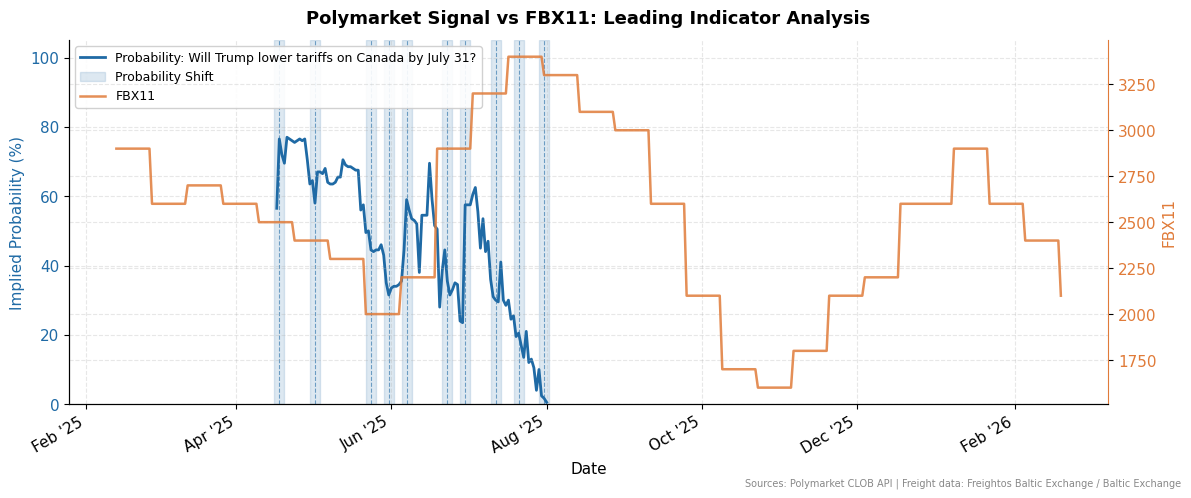

In [27]:
from src.visualization.charts import (
    plot_dual_axis_overlay,
    plot_cross_correlation,
    plot_event_study,
    plot_correlation_heatmap,
    plot_annotated_timeline,
)

if xcorr_results:
    best = max(xcorr_results, key=lambda r: abs(r.peak_correlation))
    poly_df = timeseries.get(best.market_id)
    freight_df = freight_data.get(best.freight_index)
    mkt_events = (
        events_df[events_df['market_id'].astype(str) == str(best.market_id)]
        if not events_df.empty else pd.DataFrame()
    )
    event_ts = (
        list(pd.to_datetime(mkt_events['timestamp']))
        if not mkt_events.empty else []
    )
    if poly_df is not None and freight_df is not None:
        fig = plot_dual_axis_overlay(
            poly_df, freight_df,
            best.market_title, best.freight_index,
            event_timestamps=event_ts,
            filename_stem='fig1_dual_axis_hero',
        )
        plt.show()

## Chart 2: Cross-Correlation Plot

INFO:src.visualization.charts:Saved chart: output\figures\fig2_xcorr_best.png
INFO:src.visualization.charts:Saved chart: output\figures\fig2_xcorr_best.svg


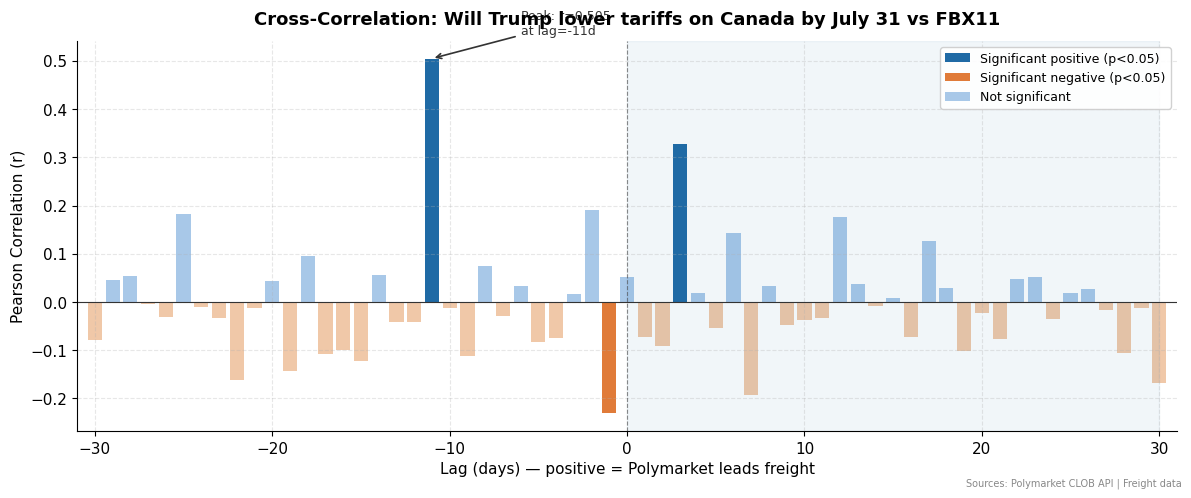

Interpretation: Peak correlation r=0.505 at lag=-11: freight LEADS Polymarket by 11 days. Higher prediction market probability → higher FBX11 rates. (p=0.000, significant)


In [28]:
if xcorr_results:
    best = max(xcorr_results, key=lambda r: abs(r.peak_correlation))
    fig = plot_cross_correlation(
        best.lags, best.correlations, best.p_values,
        best.market_title, best.freight_index,
        best.peak_lag, best.peak_correlation,
        filename_stem='fig2_xcorr_best',
    )
    plt.show()
    print(f'Interpretation: {best.interpretation}')

## Chart 3: Event Study

c:\Users\kekoi\Projects\operations_research\polymarket-scm-intel\notebooks\..\src\analysis\correlation.py:427: RuntimeWarning: Mean of empty slice
  mean_change = np.nanmean(arr, axis=0).tolist()
c:\Users\kekoi\Projects\operations_research\polymarket-scm-intel\venv\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\kekoi\Projects\operations_research\polymarket-scm-intel\notebooks\..\src\analysis\correlation.py:429: RuntimeWarning: Mean of empty slice
  ci_lower = (np.nanmean(arr, axis=0) - 1.96 * se).tolist()
c:\Users\kekoi\Projects\operations_research\polymarket-scm-intel\notebooks\..\src\analysis\correlation.py:430: RuntimeWarning: Mean of empty slice
  ci_upper = (np.nanmean(arr, axis=0) + 1.96 * se).tolist()
INFO:src.visualization.charts:Saved chart: output\figures\fig3_event_study_537698.png
INFO:src.visualization.charts:Saved chart: output\figures\fig3_ev

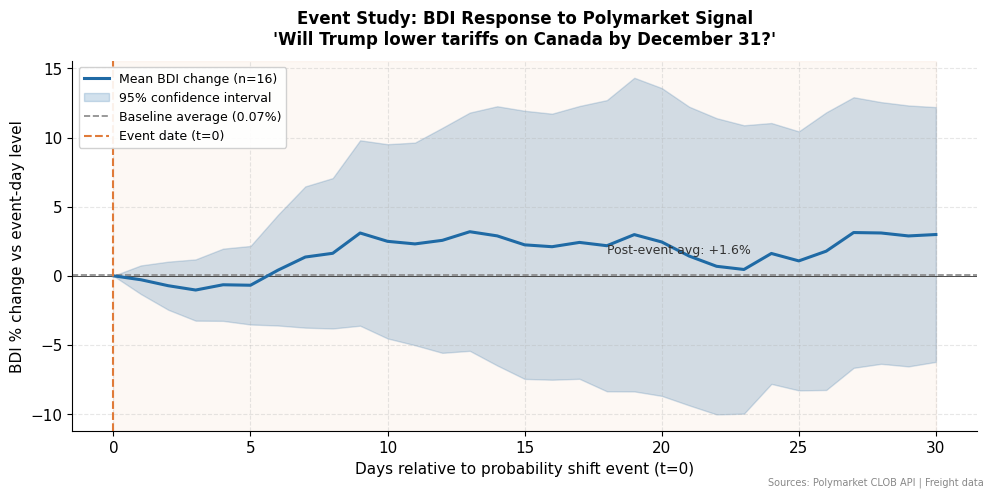

CAR (cumulative abnormal return): 1.62%


c:\Users\kekoi\Projects\operations_research\polymarket-scm-intel\notebooks\..\src\analysis\correlation.py:427: RuntimeWarning: Mean of empty slice
  mean_change = np.nanmean(arr, axis=0).tolist()
c:\Users\kekoi\Projects\operations_research\polymarket-scm-intel\venv\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\kekoi\Projects\operations_research\polymarket-scm-intel\notebooks\..\src\analysis\correlation.py:429: RuntimeWarning: Mean of empty slice
  ci_lower = (np.nanmean(arr, axis=0) - 1.96 * se).tolist()
c:\Users\kekoi\Projects\operations_research\polymarket-scm-intel\notebooks\..\src\analysis\correlation.py:430: RuntimeWarning: Mean of empty slice
  ci_upper = (np.nanmean(arr, axis=0) + 1.96 * se).tolist()
INFO:src.visualization.charts:Saved chart: output\figures\fig3_event_study_537698.png
INFO:src.visualization.charts:Saved chart: output\figures\fig3_ev

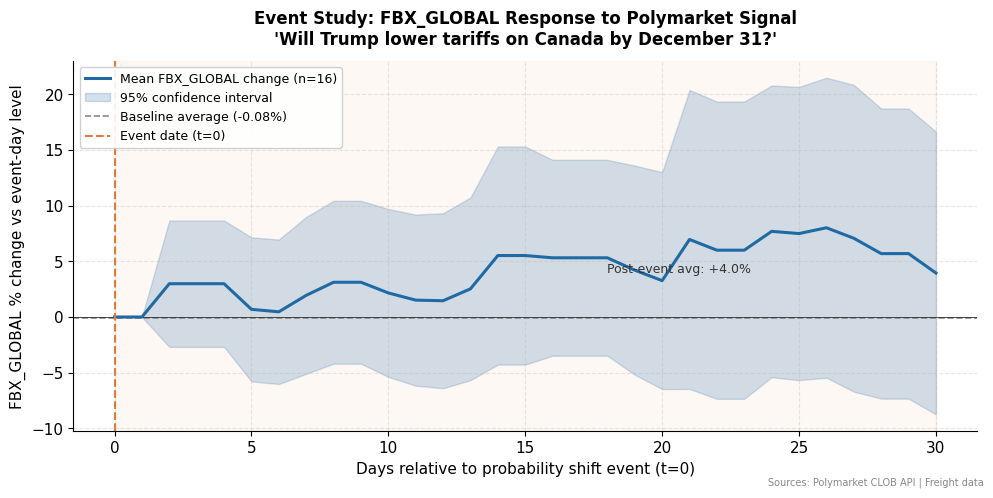

CAR (cumulative abnormal return): 4.03%


c:\Users\kekoi\Projects\operations_research\polymarket-scm-intel\notebooks\..\src\analysis\correlation.py:427: RuntimeWarning: Mean of empty slice
  mean_change = np.nanmean(arr, axis=0).tolist()
c:\Users\kekoi\Projects\operations_research\polymarket-scm-intel\venv\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\kekoi\Projects\operations_research\polymarket-scm-intel\notebooks\..\src\analysis\correlation.py:429: RuntimeWarning: Mean of empty slice
  ci_lower = (np.nanmean(arr, axis=0) - 1.96 * se).tolist()
c:\Users\kekoi\Projects\operations_research\polymarket-scm-intel\notebooks\..\src\analysis\correlation.py:430: RuntimeWarning: Mean of empty slice
  ci_upper = (np.nanmean(arr, axis=0) + 1.96 * se).tolist()
INFO:src.visualization.charts:Saved chart: output\figures\fig3_event_study_537698.png
INFO:src.visualization.charts:Saved chart: output\figures\fig3_ev

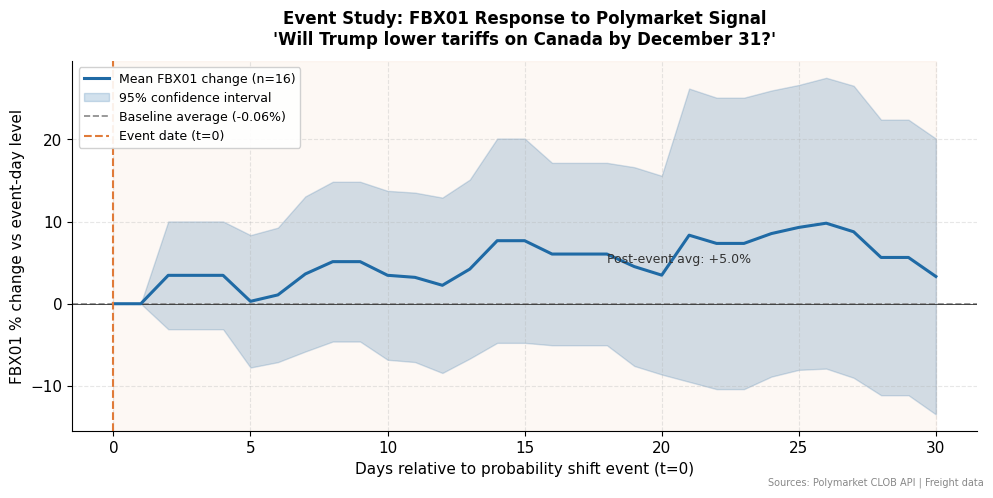

CAR (cumulative abnormal return): 4.97%


In [29]:
event_study_results = []
for r in xcorr_results[:3]:
    poly_df = timeseries.get(r.market_id)
    freight_df = freight_data.get(r.freight_index)
    if poly_df is None or freight_df is None:
        continue
    mkt_events = (
        events_df[events_df['market_id'].astype(str) == str(r.market_id)]
        if not events_df.empty else pd.DataFrame()
    )
    if mkt_events.empty:
        continue
    event_ts_list = list(pd.to_datetime(mkt_events['timestamp']))
    es = event_study(
        r.market_id, r.market_title,
        event_ts_list, freight_df, r.freight_index,
    )
    if es is not None:
        event_study_results.append(es)
        fig = plot_event_study(
            es.event_window, es.mean_freight_change,
            es.ci_lower, es.ci_upper,
            es.baseline_change,
            es.market_title, es.freight_index, es.n_events,
            filename_stem=f'fig3_event_study_{r.market_id[:8]}',
        )
        plt.show()
        print(f'CAR (cumulative abnormal return): {es.cumulative_abnormal_return:.2f}%')

## Chart 4: Correlation Heatmap

INFO:src.visualization.charts:Saved chart: output\figures\fig4_heatmap.png
INFO:src.visualization.charts:Saved chart: output\figures\fig4_heatmap.svg


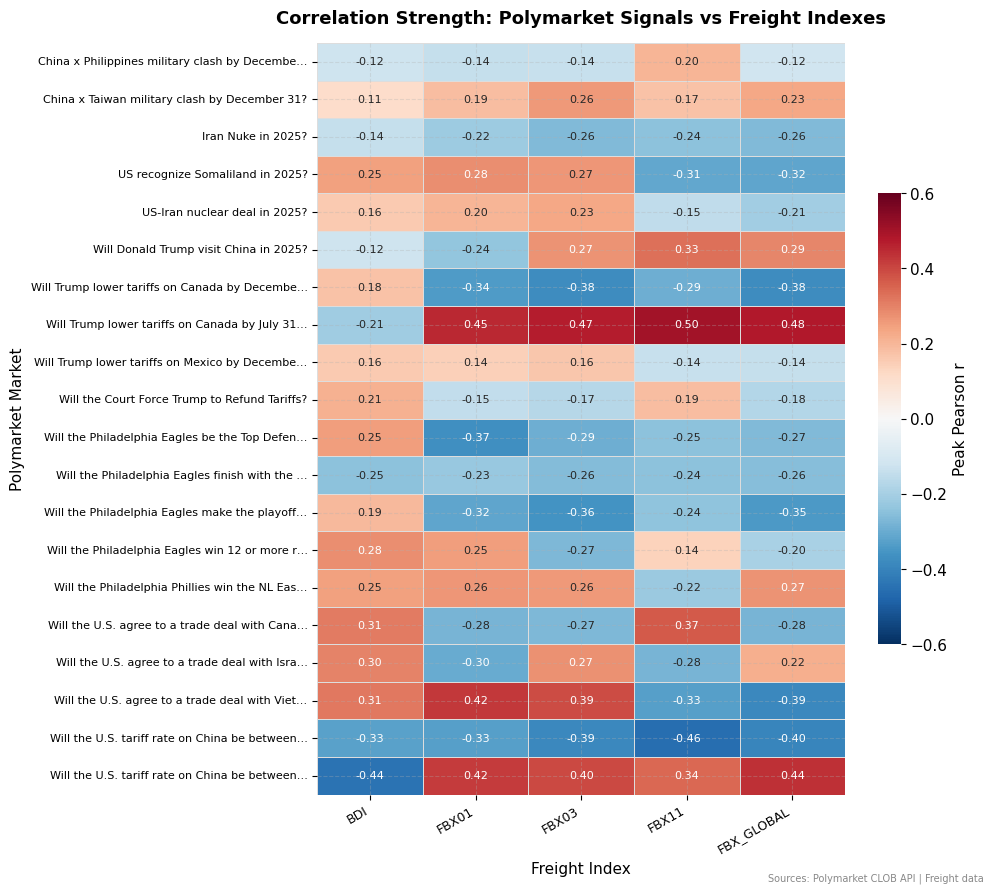

In [30]:
if not xcorr_df.empty:
    fig = plot_correlation_heatmap(xcorr_df, filename_stem='fig4_heatmap')
    plt.show()

## Chart 5: Annotated Timeline

INFO:src.visualization.charts:Saved chart: output\figures\fig5_timeline.png
INFO:src.visualization.charts:Saved chart: output\figures\fig5_timeline.svg


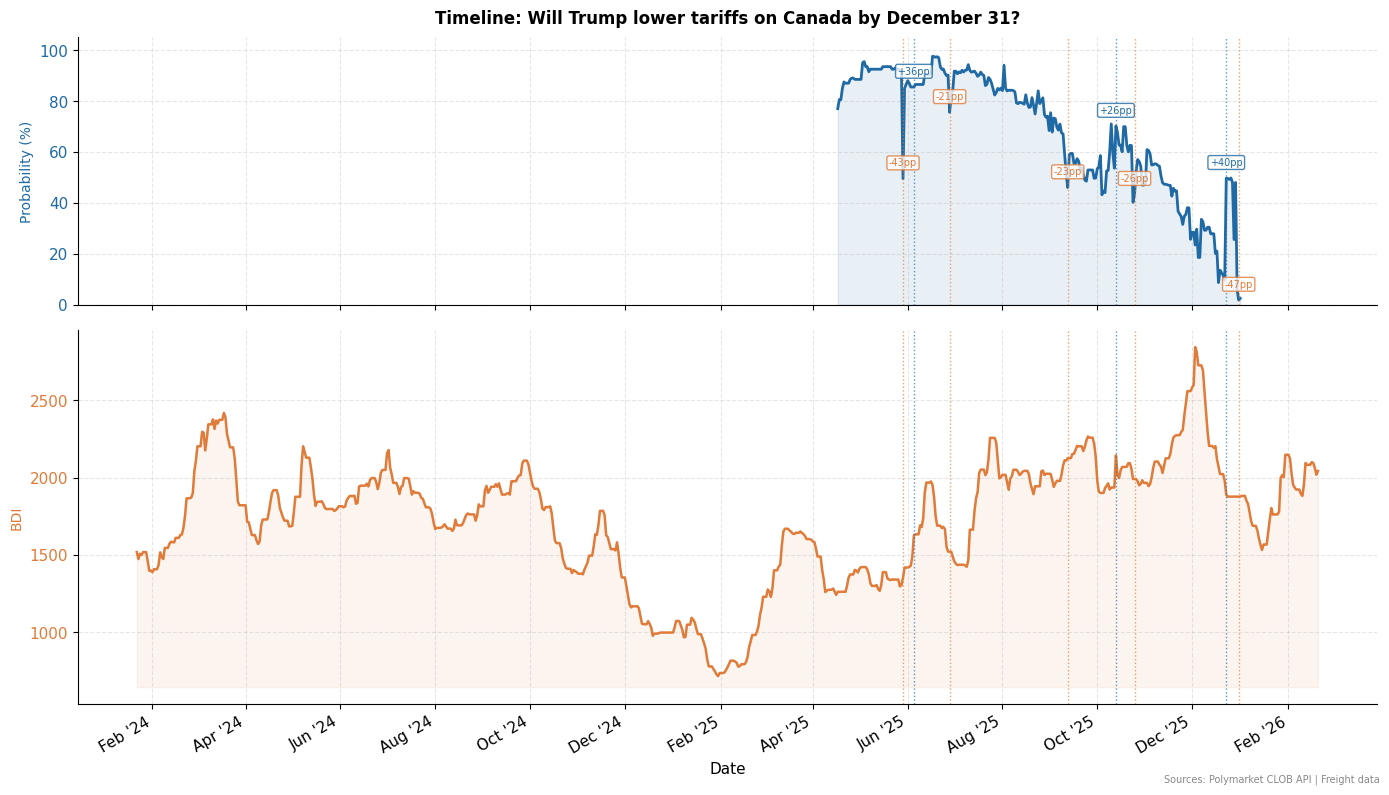

In [31]:
if xcorr_results and not events_df.empty:
    best = xcorr_results[0]
    poly_df = timeseries.get(best.market_id)
    freight_df = freight_data.get(best.freight_index)
    mkt_events = events_df[events_df['market_id'].astype(str) == str(best.market_id)]
    if poly_df is not None and freight_df is not None and not mkt_events.empty:
        fig = plot_annotated_timeline(
            poly_df, freight_df, mkt_events,
            best.market_title, best.freight_index,
            filename_stem='fig5_timeline',
        )
        plt.show()

## Generate Summary Report

In [32]:
from pathlib import Path
from datetime import datetime

output_dir = Path('../output')
output_dir.mkdir(exist_ok=True)

generated_at = datetime.now().strftime('%Y-%m-%d %H:%M UTC')

# ── Split assessments by market status ───────────────────────────────────────
# is_resolved=True  → closed/resolved markets  → backtesting report
# is_resolved=False → active/open markets       → forward-looking report
historical_assessments  = [a for a in assessments if a.is_resolved]
forward_assessments     = [a for a in assessments if not a.is_resolved]
print(f'Assessments split: {len(historical_assessments)} historical (resolved), '
      f'{len(forward_assessments)} forward-looking (active)')

# ── Shared executive summary block ───────────────────────────────────────────
def _exec_summary(tag: str) -> str:
    lines = [
        f'- **Markets discovered:** {len(markets_df)}',
        f"- **Active markets:** {(markets_df['status'] == 'active').sum()}",
        f"- **Historical (closed) markets:** {(markets_df['status'] == 'closed').sum()}",
        f'- **Markets with timeseries data:** {len(timeseries)}',
        f'- **Significant probability shift events detected:** {len(all_events)}',
        f'- **Market-freight pairings analysed:** {len(xcorr_results)}',
        f"- **Statistically significant correlations (p < 0.05):** {xcorr_df['is_significant'].sum() if not xcorr_df.empty else 0}",
        f'- **Granger causality tests run:** {len(granger_results)}',
        f"- **Significant Granger results:** {granger_df['is_significant'].sum() if not granger_df.empty else 0}",
        f'- **Assessments in this report ({tag}):** {len(historical_assessments) if tag == "backtesting" else len(forward_assessments)}',
    ]
    return '\n'.join(lines)

def _xcorr_section() -> str:
    lines = ['### Cross-Correlation Results']
    if not xcorr_df.empty:
        for _, row in xcorr_df.sort_values('peak_correlation', ascending=False).head(5).iterrows():
            leads = 'Polymarket LEADS' if row['polymarket_leads'] else 'Freight leads'
            sig = 'significant' if row['is_significant'] else 'not significant'
            lines.append(
                f"- **{row['market_title'][:50]}** × {row['freight_index']}: "
                f"r={row['peak_correlation']:.3f}, lag={row['peak_lag_days']}d ({leads}, {sig})"
            )
    return '\n'.join(lines)

def _granger_section() -> str:
    lines = ['### Granger Causality']
    if not granger_df.empty:
        for _, row in granger_df.sort_values('min_p_value').head(5).iterrows():
            sig = 'SIGNIFICANT' if row['is_significant'] else 'not significant'
            lines.append(
                f"- **{row['market_title'][:50]}** → {row['freight_index']}: "
                f"p={row['min_p_value']:.4f} at lag={row['best_lag']}d ({sig})"
            )
    return '\n'.join(lines)

def _figures_section() -> str:
    lines = ['## Figures Generated']
    figures_dir = Path('../output/figures')
    if figures_dir.exists():
        for fig_file in sorted(figures_dir.glob('*.png')):
            lines.append(f'- {fig_file.name}')
    return '\n'.join(lines)

# ── Detect which freight indexes used synthetic data ──────────────────────────
_freight_dir = Path('data/freight')
_synthetic_indexes = sorted(
    f.stem.replace('_synthetic', '').upper()
    for f in _freight_dir.glob('*_synthetic.csv')
) if _freight_dir.exists() else []

_caveat_items = []
if _synthetic_indexes:
    _synthetic_names = ', '.join(_synthetic_indexes)
    _caveat_items.append(
        f'**Synthetic freight data**: Synthetic data was generated for {_synthetic_names}. '
        'Final analysis requires real BDI/FBX data.'
    )
_caveat_items += [
    '**Correlation ≠ causation**: Statistical relationships documented here are consistent with the leading indicator thesis but require further validation.',
    '**Sample size**: Some pairings have limited overlapping observations, reducing statistical power.',
    '**Market selection bias**: Markets were selected by keyword matching; some relevant markets may be missed.',
    '**Data gaps**: Some Polymarket timeseries have gaps that could affect correlation estimates.',
]
CAVEATS = '## Caveats and Limitations\n' + '\n'.join(
    f'{i + 1}. {item}' for i, item in enumerate(_caveat_items)
)

# ── Report A: Backtesting ─────────────────────────────────────────────────────
backtest_lines = [
    '# Polymarket SCM Intel — Backtesting Report',
    '*Historical signal validation: closed/resolved markets only*',
    f'*Generated: {generated_at}*',
    '---',
    '## Overview',
    'This report covers **resolved Polymarket contracts** — markets where the outcome is already '
    'known. It validates the leading-indicator thesis by comparing probability shifts detected '
    'before resolution against observed freight rate movements in the subsequent days.',
    '---',
    '## Pipeline Statistics',
    _exec_summary('backtesting'),
    '---',
    '## Correlation Analysis',
    _xcorr_section(),
    '---',
    _granger_section(),
    '---',
    mapper.generate_backtesting_report_section(assessments, top_n=10),
    '---',
    _figures_section(),
    '---',
    CAVEATS,
    '---',
    '*Polymarket SCM Intelligence MVP — Backtesting Report*',
]
backtest_text = '\n\n'.join(backtest_lines)
backtest_path = output_dir / 'report_backtesting.md'
backtest_path.write_text(backtest_text, encoding='utf-8')
print(f'Backtesting report saved → {backtest_path.resolve()}')

# ── Report B: Forward-Looking ─────────────────────────────────────────────────
forward_lines = [
    '# Polymarket SCM Intel — Forward-Looking Intelligence Report',
    '*Live supply chain signals: active/open markets only*',
    f'*Generated: {generated_at}*',
    '---',
    '## Overview',
    'This report covers **active Polymarket contracts** — markets still trading with unresolved '
    'outcomes. Each probability shift identified here represents a live market signal about '
    'near-term geopolitical or trade risk. Supply chain teams can use these signals as early '
    'warning indicators before freight rate movements materialise.',
    '---',
    '## Pipeline Statistics',
    _exec_summary('forward'),
    '---',
    '## Correlation Analysis (full dataset)',
    _xcorr_section(),
    '---',
    _granger_section(),
    '---',
    mapper.generate_forward_looking_report_section(assessments, top_n=10),
    '---',
    _figures_section(),
    '---',
    CAVEATS,
    '---',
    '*Polymarket SCM Intelligence MVP — Forward-Looking Intelligence Report*',
]
forward_text = '\n\n'.join(forward_lines)
forward_path = output_dir / 'report_forward_looking.md'
forward_path.write_text(forward_text, encoding='utf-8')
print(f'Forward-looking report saved → {forward_path.resolve()}')

# ── Combined report (kept for backward compatibility) ─────────────────────────
combined_lines = [
    '# Polymarket Supply Chain Intelligence - Analysis Report',
    f'*Generated: {generated_at}*',
    '---',
    '## Executive Summary',
    _exec_summary('combined'),
    '',
    f'> **Two specialised reports have also been generated:**',
    f'> - `output/report_backtesting.md` — {len(historical_assessments)} assessments from resolved markets',
    f'> - `output/report_forward_looking.md` — {len(forward_assessments)} assessments from active markets',
    '---',
    '## Key Findings',
    _xcorr_section(),
    '---',
    _granger_section(),
    '---',
    mapper.generate_report_section(assessments, top_n=5),
    '---',
    _figures_section(),
    '---',
    CAVEATS,
    '---',
    '*Report generated by Polymarket SCM Intelligence MVP pipeline.*',
]
combined_text = '\n\n'.join(combined_lines)
combined_path = output_dir / 'report.md'
combined_path.write_text(combined_text, encoding='utf-8')
print(f'Combined report saved → {combined_path.resolve()}')

print('\nReport preview (first 1500 chars):')
print(backtest_text[:1500])

Assessments split: 2338 historical (resolved), 555 forward-looking (active)
Backtesting report saved → C:\Users\kekoi\Projects\operations_research\polymarket-scm-intel\output\report_backtesting.md
Forward-looking report saved → C:\Users\kekoi\Projects\operations_research\polymarket-scm-intel\output\report_forward_looking.md
Combined report saved → C:\Users\kekoi\Projects\operations_research\polymarket-scm-intel\output\report.md

Report preview (first 1500 chars):
# Polymarket SCM Intel — Backtesting Report

*Historical signal validation: closed/resolved markets only*

*Generated: 2026-02-22 12:55 UTC*

---

## Overview

This report covers **resolved Polymarket contracts** — markets where the outcome is already known. It validates the leading-indicator thesis by comparing probability shifts detected before resolution against observed freight rate movements in the subsequent days.

---

## Pipeline Statistics

- **Markets discovered:** 35912
- **Active markets:** 12889
- **Historical (cl

## Complete
All whitepaper figures and the summary report have been generated.

Figures are saved in output/figures/ (PNG + SVG). Report is at output/report.md.